# Zennevallei XGBoost pipeline â€” 22 June 2026

This executable notebook reproduces the complete scenario-model pipeline: authoritative source validation, clear-Landsat cohort construction, 100 m land-cover feature extraction, spatial cross-validation, 50-trial Optuna tuning, leakage-aware feature elimination, all-data candidate training and the guarded deployment decision.

The target is daytime Landsat land-surface temperature, not air temperature. The fitted relationship is observational and must not be interpreted as a causal intervention effect.

## Pipeline and reproducibility contract

1. Validate the 22 June 2026 Landsat raster and the aligned 2021/2024 land-cover sources.
2. Keep every clear finite Landsat centre in Zennevallei with a completely valid 100 m surroundings. No urban-fabric or sealed-surface mask is applied.
3. Measure Sealed, High vegetation, Low vegetation, Agriculture and Water fractions in radial rings. Other unsealed land is the implicit remainder.
4. Evaluate every Optuna recipe over the same five sector-held-out folds with a 200 m embargo.
5. Remove features only within the fixed 0.01Â°C pooled-RMSE tolerance.
6. Train the candidate on the complete eligible cohort using the median held-out best-round count.
7. Replace production only when the complete paired sector-bootstrap RMSE interval is below zero.

Running from an empty cache performs every stage. Existing validated artefacts and the resumable SQLite study are reused.

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import optuna
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import mapping
import xgboost as xgb

from greenwave_local_layers.constants import PROJECT_ROOT
from greenwave_local_layers.image_regression import (
    DEFAULT_OBSERVATION_ID, prepare_regression_catalog,
)
from greenwave_local_layers.image_regression_optuna import (
    OPTUNA_ROOT, REPORT_OUTPUT_PATH, PREDICTIONS_PATH, FEATURES_PATH,
    STUDY_NAME, STUDY_PATH, build_optuna_folds, extract_optuna_features,
    run_optuna_benchmark,
)
from greenwave_local_layers.image_regression_xgboost_pipeline import MODEL_PATH, REPORT_PATH

TRIALS = 100
DEVICE = 'cuda'
FORCE_REBUILD_INPUTS = False
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)
print({'observation': DEFAULT_OBSERVATION_ID, 'trials': TRIALS, 'device_requested': DEVICE})

C:\Users\Necro\Documents\Greenwave\processing\local-layers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'observation': 'landsat-2026-06-22', 'trials': 100, 'device_requested': 'cuda'}


## 1. Source validation and preprocessing

The preparation helper validates source hashes and alignment, rasterises Urban Atlas water and product validity, identifies clear Landsat centres inside the 154 Statbel sectors, and rejects centres whose complete 100 m disk contains invalid land-cover data.

In [2]:
catalog = prepare_regression_catalog(
    DEFAULT_OBSERVATION_ID, force=FORCE_REBUILD_INPUTS,
)
samples = catalog.samples.reset_index(drop=True)
manifest = catalog.manifest

def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

source_rows = []
for source_id, signature in manifest['sources'].items():
    source_rows.append({
        'source': source_id,
        'file': Path(signature['path']).name,
        'size_MiB': signature['size'] / 1024**2,
        'sha256': signature['sha256'][:16] + 'â€¦',
    })
source_table = pd.DataFrame(source_rows)
display(source_table.style.format({'size_MiB': '{:.2f}'}))
display(pd.Series({
    'eligible observations': len(samples),
    'statistical sectors': samples.sector_id.nunique(),
    'municipalities': samples.municipality.nunique(),
    'minimum LST (Â°C)': samples.lst_c.min(),
    'maximum LST (Â°C)': samples.lst_c.max(),
    'mean LST (Â°C)': samples.lst_c.mean(),
}, name='value').to_frame())

,source,file,size_MiB,sha256
0,landsat,landsat-2026-06-22.tif,1.67,a5e73a38136008ceâ€¦
1,soilSealing,jaarbak-2024-halo.tif,5.47,3b95eec9999c57ceâ€¦
2,greenMap,groenkaart-2021-halo.tif,9.89,04b3d82887cbab2bâ€¦
3,sectors,sectors.geojson,1.08,6c37e0d0e811ab8fâ€¦
4,urbanAtlas,CLMS_UA_LCU_S2021_V025ha_BE001L3_BRUXELLES_BRUSSEL_LEUVEN_03035_V01_R01_20250730.fgb,170.61,3c55e3ee31ac6276â€¦
5,urbanContext,urban-atlas-2021-context.tif,4.18,d6a1bb92466b6e50â€¦


,value
eligible observations,192595.000000
statistical sectors,154.000000
municipalities,7.000000
minimum LST (Â°C),12.652832
maximum LST (Â°C),50.955170
mean LST (Â°C),30.561919


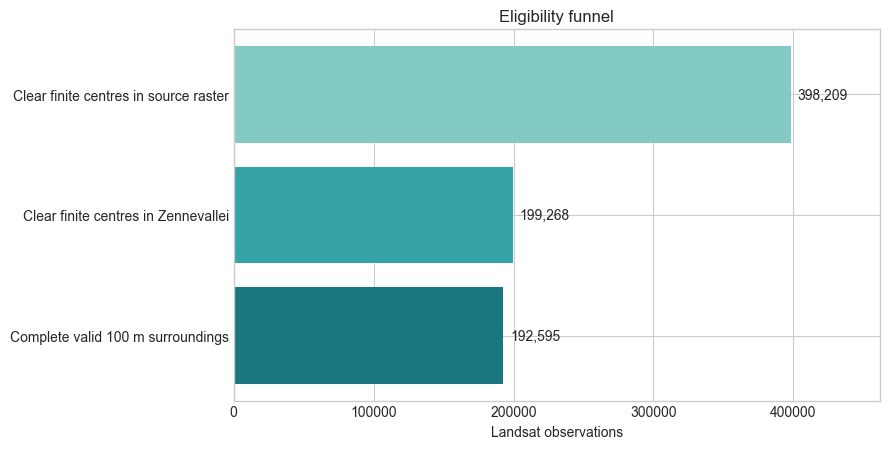

No Urban Atlas urban-fabric or sealed-ground selection is used in this cohort.


In [3]:
landsat_path = project_path(manifest['sources']['landsat']['path'])
sector_path = project_path(manifest['sources']['sectors']['path'])
sectors = gpd.read_file(sector_path)
with rasterio.open(landsat_path) as dataset:
    temperature = dataset.read(1)
    status = dataset.read(2)
    clear = (status == 1) & np.isfinite(temperature) & (temperature != dataset.nodata)
    sector_union = sectors.to_crs(dataset.crs).geometry.union_all()
    inside = geometry_mask(
        [mapping(sector_union)], out_shape=dataset.shape, transform=dataset.transform, invert=True,
    )
funnel = pd.Series({
    'Clear finite centres in source raster': int(clear.sum()),
    'Clear finite centres in Zennevallei': int((clear & inside).sum()),
    'Complete valid 100 m surroundings': int(len(samples)),
})
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(funnel.index[::-1], funnel.values[::-1], color=['#1b777f', '#36a3a8', '#83c9c4'])
ax.bar_label(bars, labels=[f'{value:,}' for value in funnel.values[::-1]], padding=5)
ax.set(xlabel='Landsat observations', title='Eligibility funnel')
ax.set_xlim(0, funnel.max() * 1.16)
plt.tight_layout(); plt.show()
print('No Urban Atlas urban-fabric or sealed-ground selection is used in this cohort.')

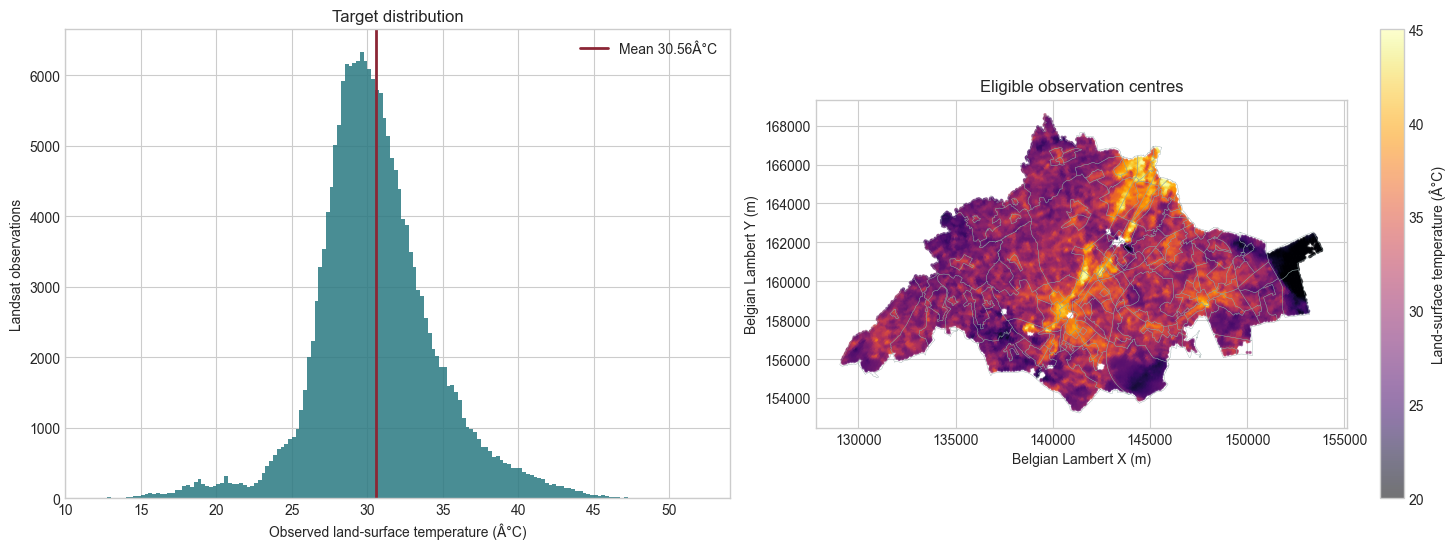

In [4]:
plot_step = max(1, len(samples) // 35_000)
plot_samples = samples.iloc[::plot_step]
sectors_lambert = sectors.to_crs('EPSG:31370')
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
axes[0].hist(samples.lst_c, bins=np.arange(12, 52.25, .25), color='#2b7a82', alpha=.86)
axes[0].axvline(samples.lst_c.mean(), color='#8b2635', lw=2, label=f'Mean {samples.lst_c.mean():.2f}Â°C')
axes[0].set(xlabel='Observed land-surface temperature (Â°C)', ylabel='Landsat observations', title='Target distribution')
axes[0].legend()
sectors_lambert.boundary.plot(ax=axes[1], color='#8da2a1', linewidth=.25)
points = axes[1].scatter(
    plot_samples.x_lambert, plot_samples.y_lambert, c=plot_samples.lst_c,
    s=2, alpha=.55, cmap='inferno', vmin=20, vmax=45, rasterized=True,
)
axes[1].set(title='Eligible observation centres', xlabel='Belgian Lambert X (m)', ylabel='Belgian Lambert Y (m)', aspect='equal')
fig.colorbar(points, ax=axes[1], label='Land-surface temperature (Â°C)')
fig.tight_layout(); plt.show()

## 2. Physical feature engineering

Each predictor is an exact 1 m area fraction within a radial band around a native 30 m Landsat observation. The support is always 100 m; Optuna chooses 10, 20 or 25 m ring widths. Ground categories are mutually exclusive, while High vegetation is a separate canopy predictor and may overlap supported ground.

In [5]:
matrices, targets, names_by_width = extract_optuna_features(
    catalog, force=FORCE_REBUILD_INPUTS,
)
feature_contract = pd.DataFrame([
    {
        'ring width (m)': width,
        'rings': 100 // width,
        'predictors': matrix.shape[1],
        'observations': matrix.shape[0],
        'finite': bool(np.isfinite(matrix).all()),
    }
    for width, matrix in matrices.items()
]).sort_values('ring width (m)')
display(feature_contract)
assert all(matrix.shape[0] == len(samples) for matrix in matrices.values())
assert np.array_equal(targets, samples.lst_c.to_numpy(dtype=np.float32))

,ring width (m),rings,predictors,observations,finite
0,5,20,100,192595,True
1,10,10,50,192595,True
2,20,5,25,192595,True
3,25,4,20,192595,True
4,50,2,10,192595,True


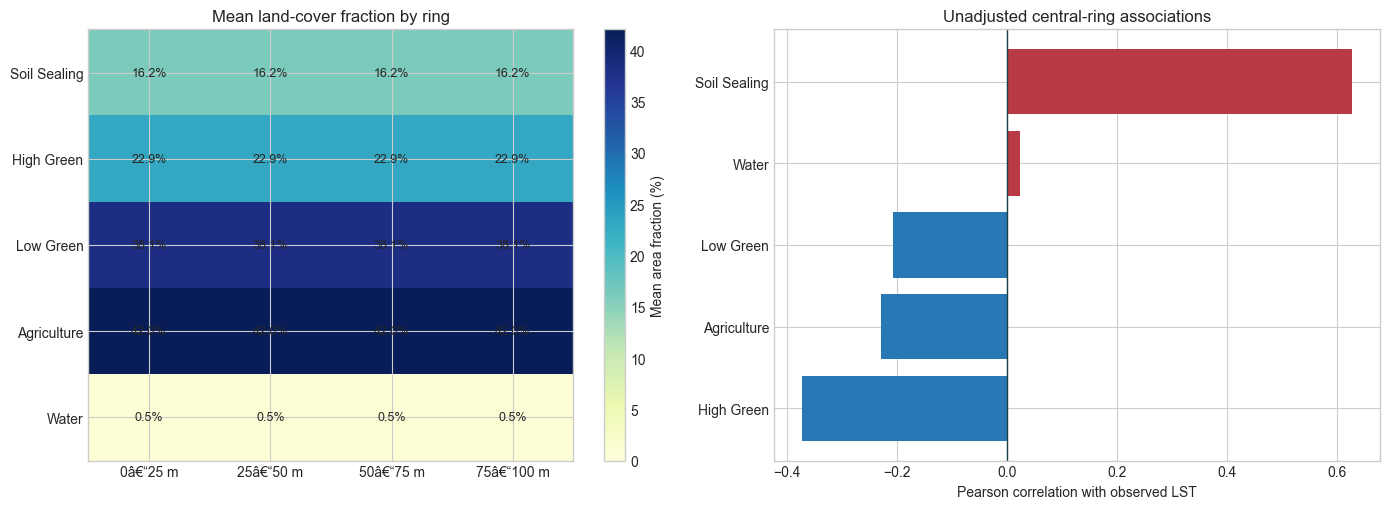

These marginal correlations are descriptive; the fitted model uses the joint feature set.


In [6]:
preview_width = 25
preview_names = names_by_width[preview_width]
preview = matrices[preview_width]
channels = ['soil_sealing', 'high_green', 'low_green', 'agriculture', 'water']
ring_labels = ['0â€“25 m', '25â€“50 m', '50â€“75 m', '75â€“100 m']
means = preview.mean(axis=0).reshape(len(channels), len(ring_labels)) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
image = axes[0].imshow(means, cmap='YlGnBu', aspect='auto', vmin=0, vmax=max(1, means.max()))
axes[0].set(xticks=range(len(ring_labels)), xticklabels=ring_labels, yticks=range(len(channels)), yticklabels=[name.replace('_', ' ').title() for name in channels], title='Mean land-cover fraction by ring')
for row in range(means.shape[0]):
    for column in range(means.shape[1]):
        axes[0].text(column, row, f'{means[row, column]:.1f}%', ha='center', va='center', fontsize=9)
fig.colorbar(image, ax=axes[0], label='Mean area fraction (%)')
central = pd.DataFrame(preview[:, ::4], columns=[name for name in preview_names[::4]])
correlations = central.assign(lst_c=targets).corr().loc['lst_c'].drop('lst_c').sort_values()
axes[1].barh([name.replace('_0_25m', '').replace('_', ' ').title() for name in correlations.index], correlations.values, color=np.where(correlations.values < 0, '#2878b5', '#b73a45'))
axes[1].axvline(0, color='#173f48', lw=1)
axes[1].set(xlabel='Pearson correlation with observed LST', title='Unadjusted central-ring associations')
fig.tight_layout(); plt.show()
print('These marginal correlations are descriptive; the fitted model uses the joint feature set.')

## 3. Spatial validation folds

Whole statistical sectors are assigned to five held-out folds. Training observations within 200 m of the held-out sector geometry are embargoed so the 100 m land-cover supports cannot overlap across the split. The same observations, folds and targets are used for every trial.

,fold,trainSampleCount,testSampleCount,excludedBufferSampleCount,trainSectorCount,testSectorCount,bufferMeters
0,0,126100,38520,27975,122,30,200.0
1,1,128690,38515,25390,122,31,200.0
2,2,127778,38512,26305,121,31,200.0
3,3,128433,38522,25640,119,31,200.0
4,4,130320,38526,23749,119,31,200.0


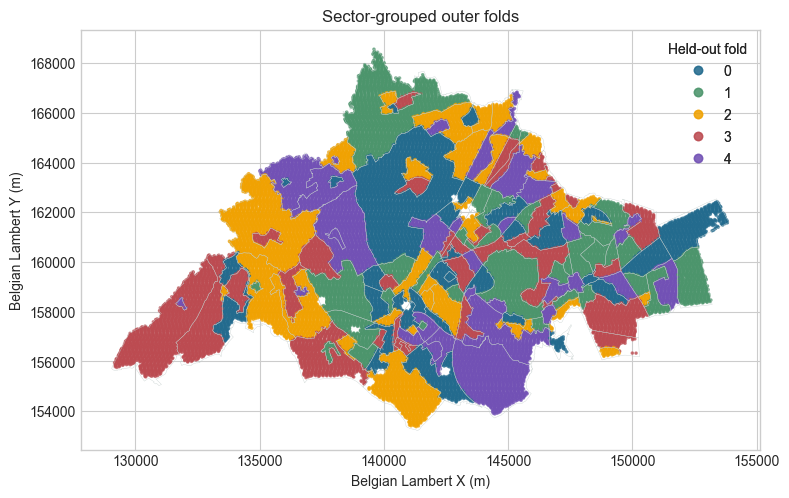

In [7]:
folds = build_optuna_folds(samples)
fold_assignments = np.full(len(samples), -1, dtype=np.int8)
fold_rows = []
for fold in folds:
    fold_assignments[fold.test_indices] = fold.fold
    fold_rows.append({'fold': fold.fold, **fold.diagnostics})
fold_table = pd.DataFrame(fold_rows)
display(fold_table[['fold', 'trainSampleCount', 'testSampleCount', 'excludedBufferSampleCount', 'trainSectorCount', 'testSectorCount', 'bufferMeters']])
assert np.all(fold_assignments >= 0)
fig, ax = plt.subplots(figsize=(8, 7.2))
sectors_lambert.boundary.plot(ax=ax, color='#c4cecc', linewidth=.25)
fold_plot = samples.iloc[::plot_step]
colours = ListedColormap(['#236b8e', '#4c956c', '#f0a202', '#bc4b51', '#7251b5'])
points = ax.scatter(fold_plot.x_lambert, fold_plot.y_lambert, c=fold_assignments[::plot_step], cmap=colours, s=2.5, alpha=.65, rasterized=True)
legend = ax.legend(*points.legend_elements(), title='Held-out fold', loc='upper right')
ax.add_artist(legend)
ax.set(title='Sector-grouped outer folds', xlabel='Belgian Lambert X (m)', ylabel='Belgian Lambert Y (m)', aspect='equal')
plt.tight_layout(); plt.show()

## 4. Five-fold Optuna tuning

A seeded TPE study tunes exactly ten choices: ring width, prediction-smoothing sigma and eight XGBoost parameters. Each of the 50 completed trials trains and evaluates all five folds. Its objective is pooled out-of-fold RMSE, not the mean of fold RMSEs. Observed temperatures are never smoothed.

In [8]:
report = run_optuna_benchmark(
    trials=TRIALS, device=DEVICE, force_features=FORCE_REBUILD_INPUTS,
)
study = optuna.load_study(
    study_name=STUDY_NAME, storage=f'sqlite:///{STUDY_PATH.as_posix()}',
)
trials = study.trials_dataframe()
complete = trials.loc[trials.state == 'COMPLETE'].sort_values('number').copy()
assert len(complete) == TRIALS
assert all(len(trial.user_attrs['folds']) == 5 for trial in study.trials if trial.state.name == 'COMPLETE')
display(pd.Series({
    'completed trials': report['completedTrials'],
    'best trial': report['bestTrial']['number'],
    'all-feature pooled RMSE (Â°C)': report['bestTrial']['allFeatureRmseC'],
    'selected-feature pooled RMSE (Â°C)': report['bestTrial']['selectedFeatureMetrics']['rmse_c'],
}, name='value').to_frame())

[I 2026-08-13 14:23:35,830] Using an existing study with name 'zennevallei-xgboost-2026-100mV2' instead of creating a new one.


C:\Users\Necro\Documents\Greenwave\processing\local-layers\src\greenwave_local_layers\image_regression_optuna.py:642: ExperimentalWarning: PedAnovaImportanceEvaluator is experimental (supported from v3.6.0). The interface can change in the future.
  study, evaluator=optuna.importance.PedAnovaImportanceEvaluator(),


,value
completed trials,100.000000
best trial,94.000000
all-feature pooled RMSE (Â°C),2.312298
selected-feature pooled RMSE (Â°C),2.316599


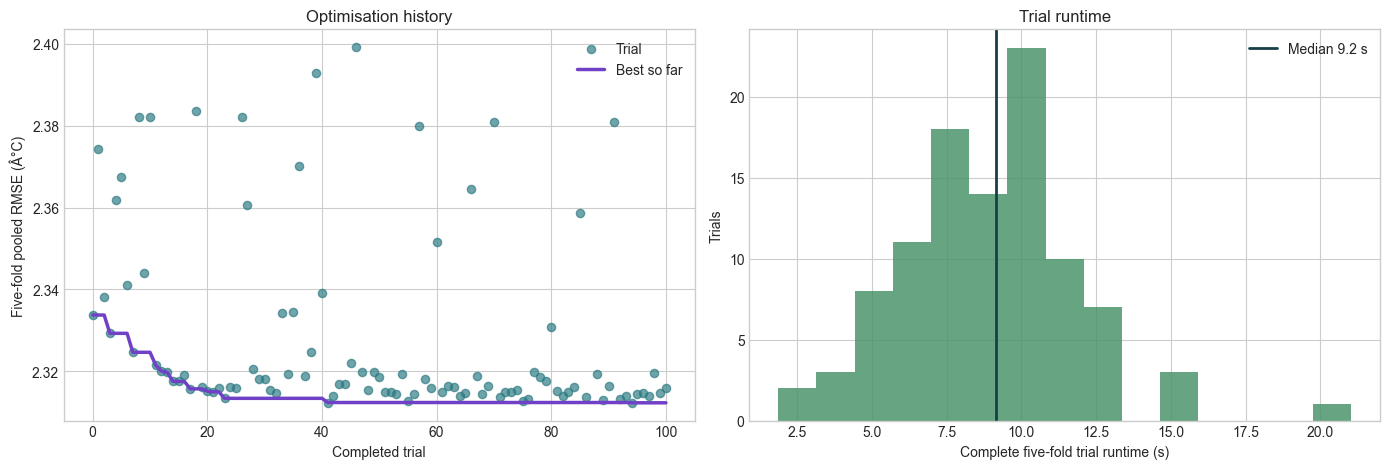

In [9]:
complete['incumbent_rmse_c'] = complete.value.cummin()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].scatter(complete.number, complete.value, s=35, alpha=.68, color='#2b7a82', label='Trial')
axes[0].plot(complete.number, complete.incumbent_rmse_c, color='#7041c7', lw=2.5, label='Best so far')
axes[0].set(xlabel='Completed trial', ylabel='Five-fold pooled RMSE (Â°C)', title='Optimisation history')
axes[0].legend()
duration = complete['user_attrs_duration_seconds']
axes[1].hist(duration, bins=15, color='#4c956c', alpha=.85)
axes[1].axvline(duration.median(), color='#173f48', lw=2, label=f'Median {duration.median():.1f} s')
axes[1].set(xlabel='Complete five-fold trial runtime (s)', ylabel='Trials', title='Trial runtime')
axes[1].legend()
fig.tight_layout(); plt.show()

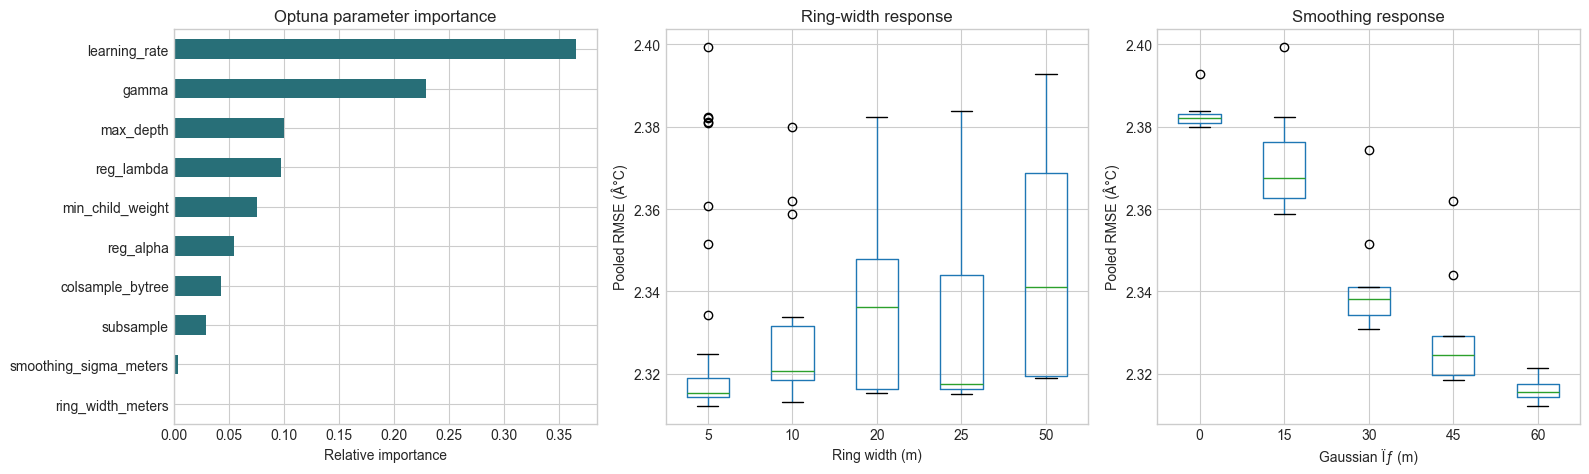

,selected value
ring_width_meters,5.000000
smoothing_sigma_meters,60.000000
learning_rate,0.035986
max_depth,8.000000
min_child_weight,1.622972
subsample,0.914149
colsample_bytree,0.920049
gamma,1.030678
reg_alpha,9.253459
reg_lambda,0.004624


In [10]:
importance = pd.Series(report.get('parameterImportance', {})).sort_values()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
importance.plot.barh(ax=axes[0], color='#286f78')
axes[0].set(title='Optuna parameter importance', xlabel='Relative importance')
complete.boxplot(column='value', by='params_ring_width_meters', ax=axes[1])
axes[1].set(title='Ring-width response', xlabel='Ring width (m)', ylabel='Pooled RMSE (Â°C)')
complete.boxplot(column='value', by='params_smoothing_sigma_meters', ax=axes[2])
axes[2].set(title='Smoothing response', xlabel='Gaussian Ïƒ (m)', ylabel='Pooled RMSE (Â°C)')
fig.suptitle(''); fig.tight_layout(); plt.show()
best_parameters = pd.Series(report['bestTrial']['parameters'], name='selected value').to_frame()
display(best_parameters)

## 5. Leakage-aware feature selection

Backward elimination calculates permutation importance only on held-out sectors. A proposed removal is accepted only while the re-evaluated pooled RMSE remains within 0.01Â°C of the all-feature Optuna optimum.

,feature,permutationImportanceC,beforeRmseC,afterRmseC,removed,status
0,high_green_5_10m,-0.0043,2.3123,2.3130,True,removed
1,high_green_50_55m,-0.0027,2.3130,2.3162,True,removed
2,high_green_35_40m,-0.0046,2.3162,2.3124,True,removed
3,low_green_85_90m,-0.0043,2.3124,2.3143,True,removed
4,low_green_0_5m,-0.0032,2.3143,2.3143,True,removed
5,high_green_75_80m,-0.0036,2.3143,2.3130,True,removed
6,agriculture_90_95m,-0.0010,2.3130,2.3121,True,removed
7,high_green_65_70m,-0.0022,2.3121,2.3137,True,removed
8,agriculture_85_90m,-0.0006,2.3137,2.3155,True,removed
9,agriculture_80_85m,-0.0030,2.3155,2.3125,True,removed


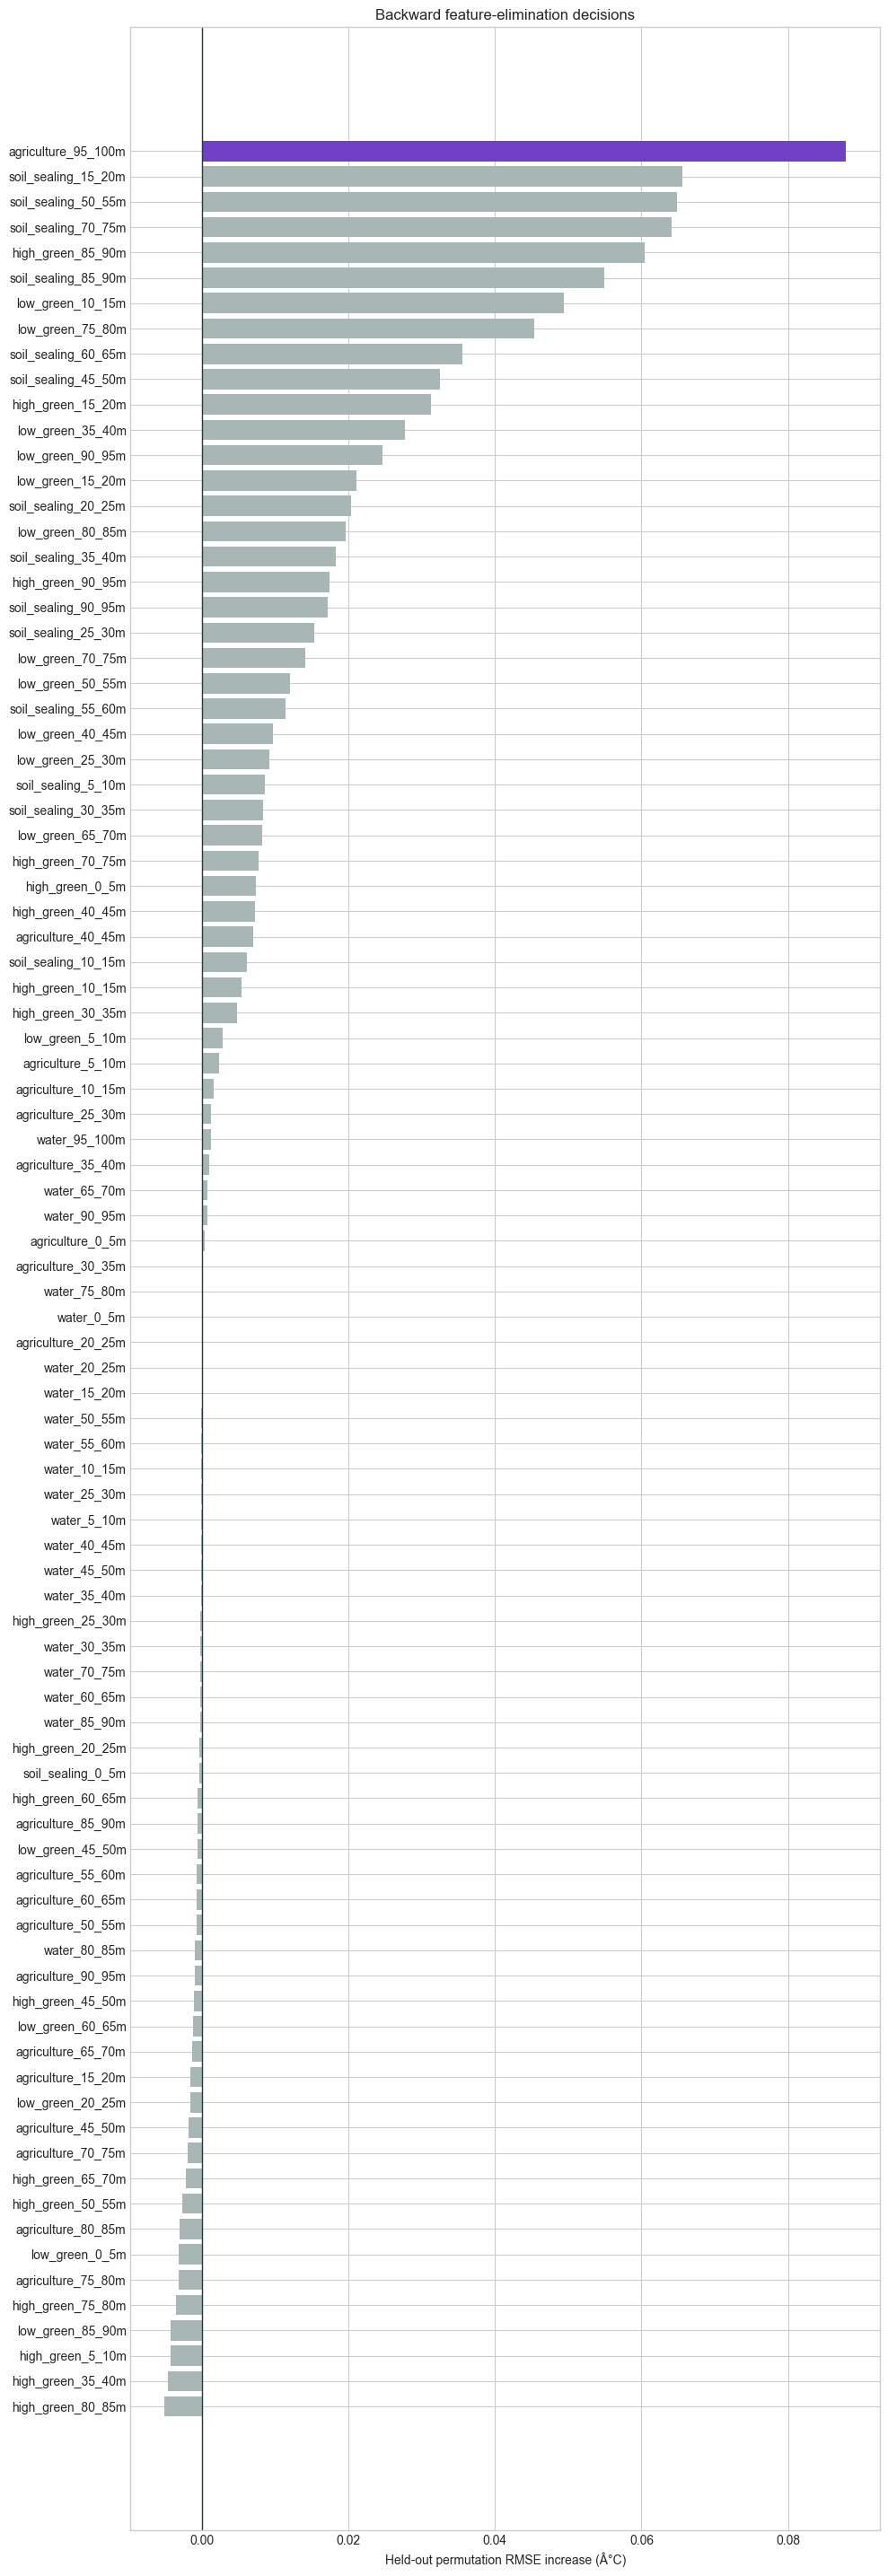

Retained 11 predictors; rejected 89.


In [11]:
selection = pd.DataFrame(report['bestTrial']['featureSelection'])
selection['status'] = np.where(selection.removed, 'removed', 'retained')
display(selection.style.format({
    'permutationImportanceC': '{:+.4f}', 'beforeRmseC': '{:.4f}', 'afterRmseC': '{:.4f}',
}))
fig, ax = plt.subplots(figsize=(10, max(4, len(selection) * .32)))
ordered = selection.sort_values('permutationImportanceC')
ax.barh(ordered.feature, ordered.permutationImportanceC, color=np.where(ordered.removed, '#a8b7b5', '#7041c7'))
ax.axvline(0, color='#173f48', lw=1)
ax.set(xlabel='Held-out permutation RMSE increase (Â°C)', title='Backward feature-elimination decisions')
plt.tight_layout(); plt.show()
print(f"Retained {len(report['bestTrial']['selectedFeatures'])} predictors; rejected {len(report['bestTrial']['rejectedFeatures'])}.")

## 6. Held-out performance and residual diagnostics

These are model-selection cross-validation results on the same five folds, not a separate external validation dataset. Each eligible Landsat observation receives exactly one held-out prediction.

,model,fold,count,rmse_c,mae_c,r2,mean_error_c
0,Optuna selected,0,38520,2.491,1.755,0.682,+0.027
1,Optuna selected,1,38515,2.514,1.948,0.596,+0.459
2,Optuna selected,2,38512,2.312,1.868,0.711,+0.424
3,Optuna selected,3,38522,2.154,1.722,0.573,+0.015
4,Optuna selected,4,38526,2.080,1.655,0.700,-0.931
5,Current production,0,38520,2.494,1.753,0.681,+0.021
6,Current production,1,38515,2.519,1.949,0.595,+0.464
7,Current production,2,38512,2.324,1.880,0.708,+0.410
8,Current production,3,38522,2.156,1.724,0.572,+0.017
9,Current production,4,38526,2.082,1.660,0.700,-0.939


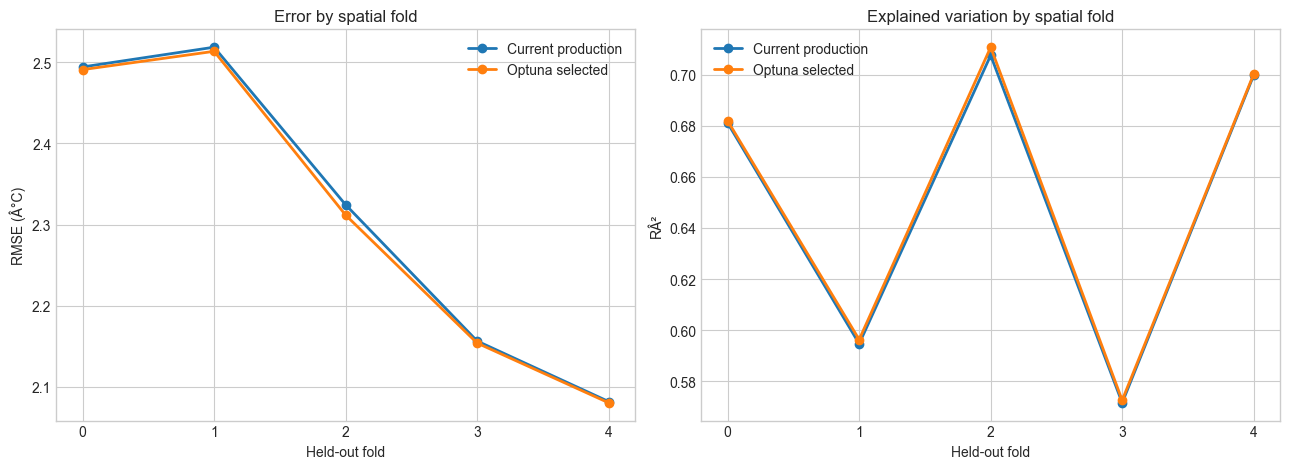

In [12]:
selected_folds = pd.DataFrame([{'model': 'Optuna selected', 'fold': item['fold'], **item['metrics']} for item in report['bestTrial']['selectedFeatureFolds']])
fold_frames = [selected_folds]
if report.get('currentProduction'):
    fold_frames.append(pd.DataFrame([{'model': 'Current production', 'fold': item['fold'], **item['metrics']} for item in report['currentProduction']['folds']]))
fold_metrics = pd.concat(fold_frames, ignore_index=True)
display(fold_metrics[['model', 'fold', 'count', 'rmse_c', 'mae_c', 'r2', 'mean_error_c']].style.format({
    'rmse_c': '{:.3f}', 'mae_c': '{:.3f}', 'r2': '{:.3f}', 'mean_error_c': '{:+.3f}',
}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for model, group in fold_metrics.groupby('model'):
    axes[0].plot(group.fold, group.rmse_c, marker='o', lw=2, label=model)
    axes[1].plot(group.fold, group.r2, marker='o', lw=2, label=model)
axes[0].set(xticks=range(5), xlabel='Held-out fold', ylabel='RMSE (Â°C)', title='Error by spatial fold')
axes[1].set(xticks=range(5), xlabel='Held-out fold', ylabel='RÂ²', title='Explained variation by spatial fold')
axes[0].legend(); axes[1].legend(); fig.tight_layout(); plt.show()

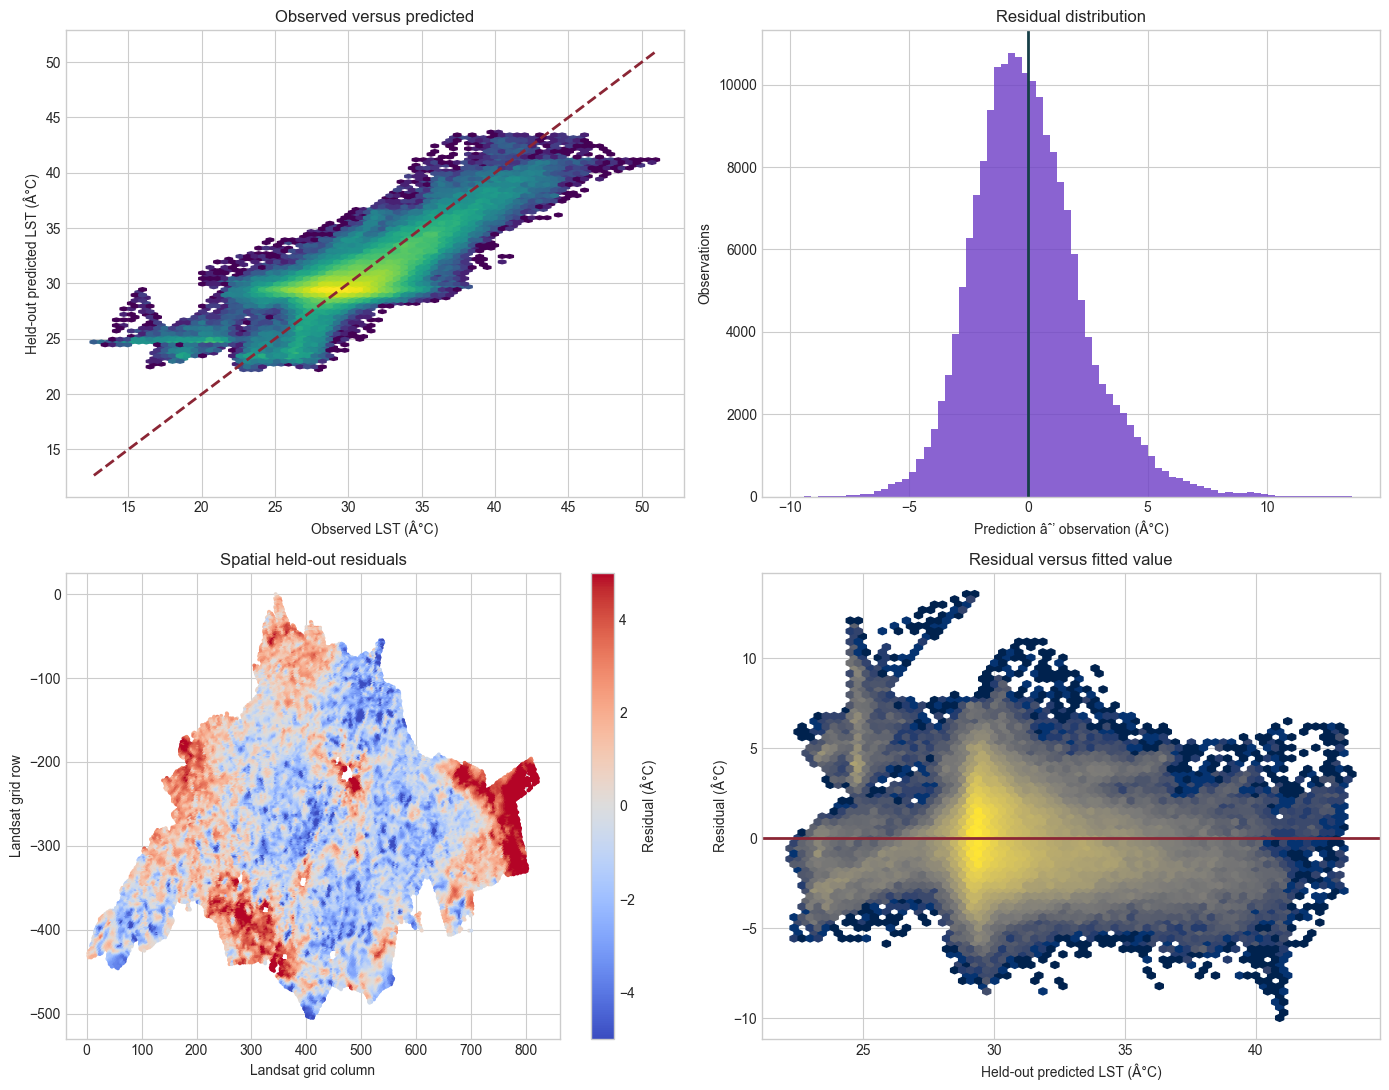

In [13]:
with np.load(PREDICTIONS_PATH, allow_pickle=False) as prediction_data:
    observed = prediction_data['observed_c']
    tuned = prediction_data['tuned_predicted_c']
    current = prediction_data['current_predicted_c']
    rows = prediction_data['landsat_rows']
    columns = prediction_data['landsat_columns']
residual = tuned - observed
diagnostic_step = max(1, len(observed) // 45_000)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes[0, 0].hexbin(observed, tuned, gridsize=75, mincnt=1, bins='log', cmap='viridis')
limits = [min(observed.min(), tuned.min()), max(observed.max(), tuned.max())]
axes[0, 0].plot(limits, limits, '--', color='#8b2635', lw=2)
axes[0, 0].set(xlabel='Observed LST (Â°C)', ylabel='Held-out predicted LST (Â°C)', title='Observed versus predicted')
axes[0, 1].hist(residual, bins=80, color='#7041c7', alpha=.82)
axes[0, 1].axvline(0, color='#173f48', lw=2)
axes[0, 1].set(xlabel='Prediction âˆ’ observation (Â°C)', ylabel='Observations', title='Residual distribution')
spatial = axes[1, 0].scatter(columns[::diagnostic_step], -rows[::diagnostic_step], c=residual[::diagnostic_step], s=3, cmap='coolwarm', vmin=-5, vmax=5, rasterized=True)
axes[1, 0].set(xlabel='Landsat grid column', ylabel='Landsat grid row', title='Spatial held-out residuals')
fig.colorbar(spatial, ax=axes[1, 0], label='Residual (Â°C)')
axes[1, 1].hexbin(tuned, residual, gridsize=70, mincnt=1, bins='log', cmap='cividis')
axes[1, 1].axhline(0, color='#8b2635', lw=2)
axes[1, 1].set(xlabel='Held-out predicted LST (Â°C)', ylabel='Residual (Â°C)', title='Residual versus fitted value')
fig.tight_layout(); plt.show()

## 7. All-data training and guarded deployment

After feature selection, the pipeline trains a candidate booster on all eligible observations. The number of boosting rounds is the median best-round count from the five held-out fits. The candidate is always saved under the experiment cache. Production is replacedâ€”and the runtime baseline inference grid regeneratedâ€”only when the paired sector bootstrap supports lower RMSE.

In [14]:
candidate_path = OPTUNA_ROOT / 'candidate-model.json'
candidate = xgb.Booster()
candidate.load_model(candidate_path)
selected_width = int(report['bestTrial']['parameters']['ring_width_meters'])
selected_names = report['bestTrial']['selectedFeatures']
selected_indices = [names_by_width[selected_width].index(name) for name in selected_names]
selected_matrix = matrices[selected_width][:, selected_indices]
training_ranges = pd.DataFrame({
    'feature': selected_names,
    'minimum': selected_matrix.min(axis=0),
    'maximum': selected_matrix.max(axis=0),
    'mean': selected_matrix.mean(axis=0),
})
display(pd.Series({
    'training observations': len(samples),
    'retained predictors': len(selected_names),
    'boosting rounds': report['bestTrial']['boostRounds'],
    'training device': report['bestTrial']['device'],
    'candidate model': str(candidate_path),
    'candidate SHA-256': report['bestTrial']['candidateModelSha256'],
}, name='value').to_frame())
display(training_ranges.style.format({'minimum': '{:.4f}', 'maximum': '{:.4f}', 'mean': '{:.4f}'}))

,value
training observations,192595
retained predictors,11
boosting rounds,94
training device,cuda
candidate model,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\cand...
candidate SHA-256,86f280c3e0c70661382a1b79f8a13c9345b12cc790afee01b6cd87260267fac3


,feature,minimum,maximum,mean
0,soil_sealing_40_45m,0.0000,1.0000,0.1617
1,soil_sealing_65_70m,0.0000,1.0000,0.1618
2,soil_sealing_75_80m,0.0000,1.0000,0.1619
3,soil_sealing_80_85m,0.0000,1.0000,0.1619
4,soil_sealing_95_100m,0.0000,1.0000,0.1620
5,high_green_55_60m,0.0000,1.0000,0.2290
6,high_green_95_100m,0.0000,1.0000,0.2290
7,low_green_30_35m,0.0000,1.0000,0.3812
8,low_green_55_60m,0.0000,1.0000,0.3812
9,low_green_95_100m,0.0000,1.0000,0.3812


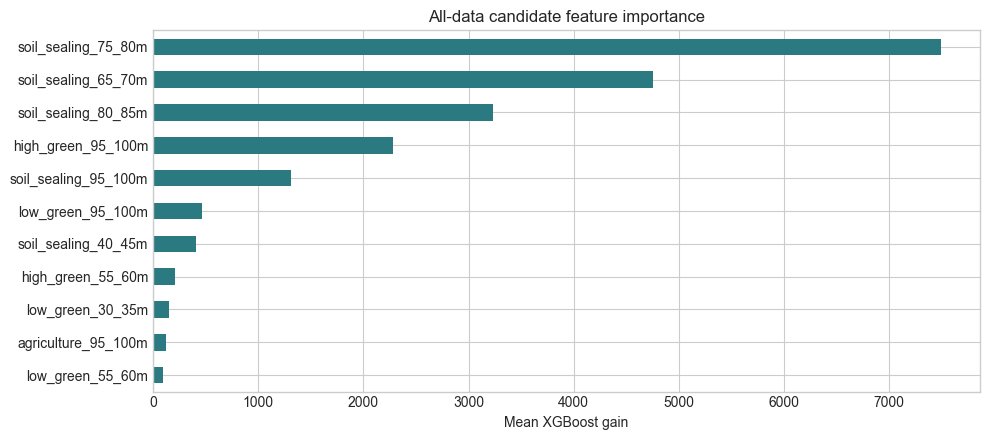

Tree gain describes the fitted candidate; it does not identify causal land-cover effects.


In [15]:
gain = candidate.get_score(importance_type='gain')
gain_series = pd.Series({name: gain.get(name, 0.0) for name in selected_names}).sort_values()
fig, ax = plt.subplots(figsize=(10, max(4.5, len(gain_series) * .36)))
gain_series.plot.barh(ax=ax, color='#2b7a82')
ax.set(xlabel='Mean XGBoost gain', title='All-data candidate feature importance')
plt.tight_layout(); plt.show()
print('Tree gain describes the fitted candidate; it does not identify causal land-cover effects.')

,rmse_c,mae_c,r2,mean_error_c
model,,,,
Optuna selected,2.3166,1.7895,0.6620,-0.0012
Current production,2.3217,1.7931,0.6605,-0.0055


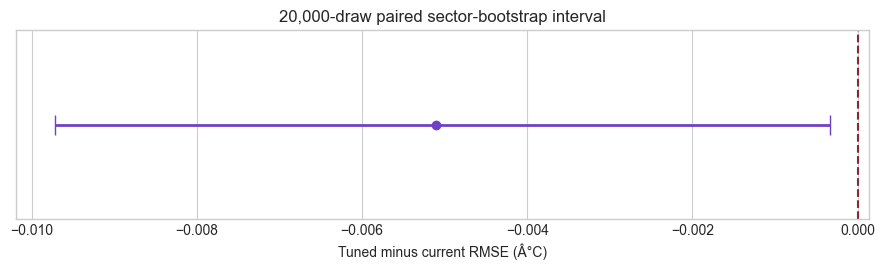

PROMOTED
The Optuna score is model-selection cross-validation, not independent external accuracy.


In [16]:
comparison_rows = [{
    'model': 'Optuna selected', **report['bestTrial']['selectedFeatureMetrics'],
}]
if report.get('currentProduction'):
    comparison_rows.append({'model': 'Current production', **report['currentProduction']['metrics']})
comparison = pd.DataFrame(comparison_rows).set_index('model')
display(comparison[['rmse_c', 'mae_c', 'r2', 'mean_error_c']].style.format('{:.4f}'))
bootstrap = report['pairedBootstrap']
if 'tunedMinusCurrentRmseCi95' in bootstrap:
    lower, upper = bootstrap['tunedMinusCurrentRmseCi95']
    point = report['bestTrial']['selectedFeatureMetrics']['rmse_c'] - report['currentProduction']['metrics']['rmse_c']
    fig, ax = plt.subplots(figsize=(9, 2.8))
    ax.errorbar(point, 0, xerr=[[point - lower], [upper - point]], fmt='o', color='#7041c7', capsize=7, lw=2)
    ax.axvline(0, color='#8b2635', ls='--')
    ax.set(yticks=[], xlabel='Tuned minus current RMSE (Â°C)', title='20,000-draw paired sector-bootstrap interval')
    plt.tight_layout(); plt.show()
decision = 'PROMOTED' if report['promoted'] else 'NOT PROMOTED â€” current production model retained'
print(decision)
print('The Optuna score is model-selection cross-validation, not independent external accuracy.')

In [17]:
artifact_paths = {
    'prepared sample catalogue': catalog.cache_dir / 'manifest.json',
    'radial feature matrices': FEATURES_PATH,
    'resumable Optuna study': STUDY_PATH,
    'trial table': OPTUNA_ROOT / 'trials.csv',
    'experiment report': REPORT_OUTPUT_PATH,
    'held-out predictions': PREDICTIONS_PATH,
    'all-data candidate model': candidate_path,
    'active production model': MODEL_PATH,
    'active production report': REPORT_PATH,
}
artifact_table = pd.DataFrame([
    {
        'artifact': label, 'path': str(path), 'exists': path.exists(),
        'size_MiB': path.stat().st_size / 1024**2 if path.exists() else np.nan,
    }
    for label, path in artifact_paths.items()
])
display(artifact_table.style.format({'size_MiB': '{:.3f}'}))
assert all(artifact_table.exists)
print(f"Production replacement performed by this run: {report['promoted']}")

,artifact,path,exists,size_MiB
0,prepared sample catalogue,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\landsat-2026-06-22\manifest.json,True,0.003
1,radial feature matrices,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\features.npz,True,69.635
2,resumable Optuna study,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\study.sqlite3,True,0.566
3,trial table,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\trials.csv,True,0.119
4,experiment report,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\report.json,True,0.031
5,held-out predictions,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\predictions.npz,True,1.692
6,all-data candidate model,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-optuna-2026\candidate-model.json,True,2.131
7,active production model,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-2026\model.json,True,2.131
8,active production report,C:\Users\Necro\Documents\Greenwave\.cache\local-layers\image-regression\xgboost-2026\report.json,True,0.025


Production replacement performed by this run: True


## Interpretation and limitations

- The training cohort covers all valid Zennevallei land-cover contexts, not only sealed or urban-fabric locations.
- Source years are mixed: Landsat 2026, Soil sealing 2024, Green Map and Urban Atlas 2021.
- Spatial folds and the embargo reduce local leakage, but the optimum remains a model-selection estimate on one observation date.
- Prediction smoothing is selected from held-out predictions only; observed temperatures are never smoothed.
- XGBoost associations do not prove that painting the corresponding land cover will cause the predicted change. The runtime scenario therefore remains explicitly exploratory.
- A production model is not replaced merely because its point estimate is slightly better. The paired sector-bootstrap promotion rule must also pass.